# Module 2: Image data — Convolutional Neural Networks


- Recognize that images have spatial structure (locality + translation equivariance)
(What is a good way to show this?)
- Understand the convolution operation
(1-D and 2-D operations)
- Show how convolution kernels can learn spatial structure
(Edge detection, design your own kernel etc)
- See empirically that a CNN learns from less data than an FC for image tasks
(Use the same MNIST data for CNN or use CIFAR for more complex images)
- Show kernels that are learned by the CNN and connect to the spatial structure of the data
https://poloclub.github.io/cnn-explainer/
- Connect to inductive bias from Module 1

## 1. What is an image?

- Show how image is a 2D array of pixel values (grayscale) or a 3D array (color images with RGB channels).
- What structures can you see from the image (horizontal edge, corners, stripies etc)? How can you tell these structures from the pixel values alone?

In [1]:
import matplotlib.pyplot as plt
from src.conv_utils import get_pixel_values
I = plt.imread('data/cameraman.bmp')
I = I.mean(axis=2)  # Convert to grayscale
ui = get_pixel_values(I, box=8);
display(ui)

## 2. What is convolution? 
Convolution is a mathematical process to describe how one function is modified by another function. The convolution equation is given by the following relationship. 
\begin{equation}
    (f \circledast g) (y) = \int_{-\infty}^{\infty} f(x)g(y-x)dx
\end{equation}
where $f$ and $g$ are two functions and $\circledast$ is the convolution operator. 

Take a look at these following examples of 1D convolution:

- Show 1-D convolution as a slider from the earlier notebook
- Apply 2-D convolution to extract different structures
(Edge detection, design your own kernel etc)

In [2]:
### setup
from src.conv_utils import (
    play_with_convolution_illustration,
)

play_with_convolution_illustration();

interactive(children=(IntSlider(value=150, description='x_i', max=400, min=-400), Dropdown(description='type',…

Here is what happens if you extend convolutions to 2-D images

In [3]:
from src.conv_utils import slide_kernel_over_image
slide_kernel_over_image(I);

interactive(children=(Dropdown(description='Kernel', index=2, options=('Vertical edge (Sobel x)', 'Horizontal …

What kind of a kernel can you design? 

In [4]:
import numpy as np
user_kernel = np.array(
    [[1, -1, 1],
     [1, -1, 1],
     [1, -1, 1]]
)

slide_kernel_over_image(I, user_kernel, size=user_kernel.shape[0]);

interactive(children=(Dropdown(description='Kernel', index=4, options=('Vertical edge (Sobel x)', 'Horizontal …

## 3. What is a CNN?

As you can see, convolutional kernels allow us to extract spatial patterns from pixel values. In fact, early computer vision algorithms relied on hand-designed kernels to extract features such as edges, corners and textures. However, this is cumbersome and not very flexible.

The idea of a Convolutional Neural Network (CNN) is to learn the weights of the convolutional kernels from data, rather than hand-designing them. Alex Krizhevsky's breakthrough paper in 2012 showed that CNNs can achieve state-of-the-art performance on image classification tasks, and since then CNNs have become the go-to architecture for image data.

### Structure of a Convolutional Layer

Earlier, you have studied how a neuron performs forward pass. 

\begin{equation*}
\tag{1}
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
\end{equation*}

Here the weights $w_i$ are the parameters of the neuron, and $b$ is the bias term. These are the parameters that are learned during training.

In a convolutional layer, the parameters are the weights of the kernels. So, the equation becomes 

\begin{equation*}
\tag{2}
y = f\left(x \circledast w + b\right)
\end{equation*}

where,

$x$ is the input image of size $H \text{(height)} \times W \text{(width)} \times C_{in} \text{(input channel)} $, 

$w$ is the kernel of size $K \text{(kernel size)}\times K \text{(kernel size)} \times C_{in} \text{(input channel)} \times C_{out} \text{(output channel)}$, and, 

$b$ is the bias term of size $C_{out}$.

The output shape of the convolutional layer depends on a number of factors: 
- The input shape (height, width, and number of channels)
- The kernel size
- The stride (how much the kernel moves at each step)
- The padding (how much zero-padding is added to the input)

Output shape can be calculated using the following formula:

\begin{equation*}
H_{out} = \left\lfloor \frac{H_{in} - K + 2P}{S} \right\rfloor + 1
\end{equation*}

\begin{equation*}
W_{out} = \left\lfloor \frac{W_{in} - K + 2P}{S} \right\rfloor + 1
\end{equation*}
where,
$H_{in}$ and $W_{in}$ are the height and width of the input image,
$K$ is the kernel size,
$P$ is the padding, and
$S$ is the stride.




### Convolutional Network Architecture

A CNN architecture combines the convolutional layers with other other layers. One common layer associated with CNN is the pooling layer. The pooling layer does not have any learnable parameters. It's main job is to reduce the spatial dimensions of the input. By doing so you can increase the *receptive field* of the network. 

Convolutional kernels at a given layer can only see a part of the input image, called the *receptive field*. By stacking multiple convolutional layers, you can increase the receptive field and allow the network to capture more global features of the image. This allows the network to learn hierarchical representations of the image, where lower layers capture local features (edges, corners) and higher layers capture more global features (object parts, whole objects).

Now, build a simple CNN architecture for image classification. 

In [11]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, image_size=28):
        super().__init__()
        self.in_channels = in_channels  
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=in_channels,  out_channels=8,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8,  out_channels=16,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=16,  out_channels=8, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=8, out_channels=8,  kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv_layer_1 = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.pool,
        )
        self.conv_layer_2 = nn.Sequential(
            self.conv2,
            nn.ReLU(),
            self.pool,
        )
        self.conv_layer_3 = nn.Sequential(
            self.conv3,
            nn.ReLU(),
            self.pool,
        )
        self.conv_layer_4 = nn.Sequential(
            self.conv4,
            nn.ReLU(),
            self.pool,
        )

        # num_features = num_channels_last_layer * height_last_layer * width_last_layer 
        num_features = 8 * (self.image_size // (2**4)) * (self.image_size // (2**4))  
        self.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_4(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x




In [29]:
# sanity check 
model = CNN(in_channels=3, num_classes=10)
input_tensor = torch.randn(64, 3, 28, 28)  # (batch_size, channels, height, width)
output = model(input_tensor)
print(f"Input shape: {input_tensor.shape}, Output shape: {output.shape}")

Input shape: torch.Size([64, 3, 28, 28]), Output shape: torch.Size([64, 10])


Copy the FCNet class from the previous module for comparison.

In [8]:
class FCNet(nn.Module):
    def __init__(self, input_dim, hidden_size, num_hidden, output_dim):
        super().__init__()
        
        self.input_layer = nn.Linear(input_dim, hidden_size)
        self.layers = []
        for _ in range(num_hidden):
            hidden_layer = nn.Linear(hidden_size, hidden_size)
            relu = nn.ReLU()
            self.layers.append(hidden_layer)
            self.layers.append(relu)

        self.hidden_layers = nn.Sequential(*self.layers)
        self.output_layer = nn.Linear(hidden_size, output_dim)

 
    def forward(self, x):
        # x has shape [batch, 1, 28, 28]
        x = x.view(x.size(0), -1)
        x = self.input_layer(x)
        x = self.hidden_layers(x)
        out = self.output_layer(x)   
        return out

In [25]:
cnn_model = CNN(in_channels=1, num_classes=10)
fc_model = FCNet(input_dim=28*28, hidden_size=64, num_hidden=2, output_dim=10)

In [21]:
cnn_num_parameters = sum(p.numel() for p in cnn_model.parameters())
fc_num_parameters = sum(p.numel() for p in fc_model.parameters())
print(f"CNN number of parameters: {cnn_num_parameters}")
print(f"FCNet number of parameters: {fc_num_parameters}")


CNN number of parameters: 3082
FCNet number of parameters: 27562


## 4. Training a CNN on MNIST dataset

In [5]:
# ----- Knobs you can turn -----
INPUT_DIM    = 28 * 28   # MNIST images flattened
OUTPUT_DIM   = 10        # 10 digit classes

LEARNING_RATE = 1e-3
NUM_EPOCHS    = 10       # try 5, 10, 20
BATCH_SIZE    = 64       # 
# --------------------------------

We will provide following functions to train and test the CNN. 

In [10]:
def evaluate(model, loader, criterion, device):
    """Compute average loss and accuracy on a dataloader."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

def train_model(model, train_loader, val_loader, num_epochs, lr, device):
    """Train the model and print train/val loss and accuracy each epoch."""
    # re-initialize model parameters
    model.apply(lambda m: isinstance(m, (nn.Linear, nn.Conv2d)) and m.reset_parameters())
    print(f"Training {model.__class__.__name__} for {num_epochs} epochs...")
    # define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # training loop
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)

        avg_train_loss, train_acc = evaluate(model, train_loader, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
              f"Train Loss: {avg_train_loss:.4f} - "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
    
    result =  {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,  
        "trained_model": model,
    }
    return result
        

Load the MNIST dataset

Train batches: 844  (54000 examples)
Val batches:   94  (6000 examples)
Test batches:  157  (10000 examples)


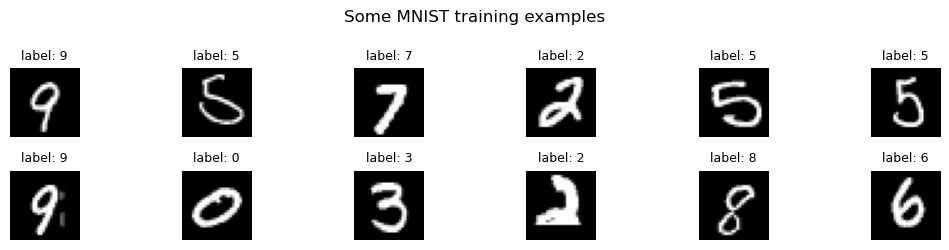

In [12]:
from src.utils import get_mnist_loaders, show_examples

train_loader, val_loader, test_loader = get_mnist_loaders(
    batch_size=64,
    val_fraction=0.1,
    train_subset_size=None,   # <-- set to e.g. 1000 to deliberately induce overfitting
    seed=0,
)

print(f"Train batches: {len(train_loader)}  ({len(train_loader.dataset)} examples)")
print(f"Val batches:   {len(val_loader)}  ({len(val_loader.dataset)} examples)")
print(f"Test batches:  {len(test_loader)}  ({len(test_loader.dataset)} examples)")

show_examples(train_loader, n=12, title="Some MNIST training examples")

In [13]:
# train the CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_result = train_model(
                        model=cnn_model.to(device), \
                        train_loader=train_loader, \
                        val_loader=val_loader, \
                        num_epochs=NUM_EPOCHS, \
                        lr=LEARNING_RATE, \
                        device=device,
                        )


Training CNN for 10 epochs...
Epoch 1/10 - Train Loss: 0.2485 - Val Loss: 0.2472 - Val Acc: 0.9283
Epoch 2/10 - Train Loss: 0.1815 - Val Loss: 0.1873 - Val Acc: 0.9462
Epoch 3/10 - Train Loss: 0.1404 - Val Loss: 0.1509 - Val Acc: 0.9578
Epoch 4/10 - Train Loss: 0.1267 - Val Loss: 0.1382 - Val Acc: 0.9580
Epoch 5/10 - Train Loss: 0.0917 - Val Loss: 0.1034 - Val Acc: 0.9695
Epoch 6/10 - Train Loss: 0.0868 - Val Loss: 0.1033 - Val Acc: 0.9670
Epoch 7/10 - Train Loss: 0.0727 - Val Loss: 0.0871 - Val Acc: 0.9747
Epoch 8/10 - Train Loss: 0.0683 - Val Loss: 0.0881 - Val Acc: 0.9737
Epoch 9/10 - Train Loss: 0.0642 - Val Loss: 0.0829 - Val Acc: 0.9745
Epoch 10/10 - Train Loss: 0.0561 - Val Loss: 0.0710 - Val Acc: 0.9777
Training FCNet for 10 epochs...
Epoch 1/10 - Train Loss: 0.1896 - Val Loss: 0.1962 - Val Acc: 0.9388
Epoch 2/10 - Train Loss: 0.1316 - Val Loss: 0.1448 - Val Acc: 0.9572
Epoch 3/10 - Train Loss: 0.0923 - Val Loss: 0.1167 - Val Acc: 0.9610
Epoch 4/10 - Train Loss: 0.0926 - Val Lo

In [ ]:
# train the FCNet
# train the FCNet
fc_result = train_model(
                        model=fc_model.to(device), \
                        train_loader=train_loader, \
                        val_loader=val_loader, \
                        num_epochs=NUM_EPOCHS, \
                        lr=LEARNING_RATE, \
                        device=device,
                        )   

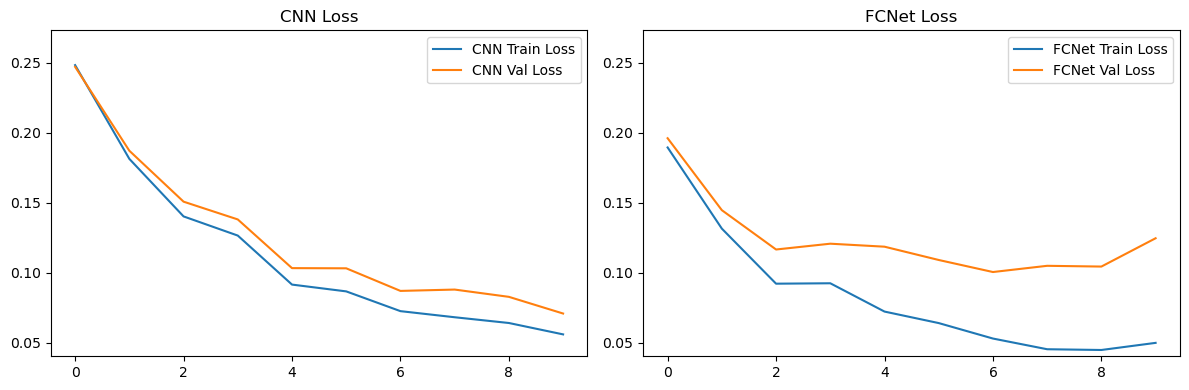

In [14]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_result["train_losses"], label="CNN Train Loss")
axes[0].plot(cnn_result["val_losses"], label="CNN Val Loss")
axes[1].plot(fc_result["train_losses"], label="FCNet Train Loss")
axes[1].plot(fc_result["val_losses"], label="FCNet Val Loss")
axes[0].set_title("CNN Loss")
axes[1].set_title("FCNet Loss")
# set y-axis to be the same for both plots
max_loss = max(max(cnn_result["train_losses"]), max(fc_result["train_losses"]))
min_loss = min(min(cnn_result["train_losses"]), min(fc_result["train_losses"]))
axes[0].set_ylim(min_loss * 0.9, max_loss * 1.1)
axes[1].set_ylim(min_loss * 0.9, max_loss * 1.1)
axes[0].legend()
axes[1].legend()
fig.tight_layout()



What do you see? 

The Fully connected network (FCNet) that you built in the previous module shows a significant difference in the training and testing accuracy. The generalisation gap is quite large compared to the CNN. This shows the inductive bias of the CNN architecture allows it to generalise better to unseen data. Does it mean they can also generalise better to out-of-distribution data?

Test it with your own hand-drawn digits!

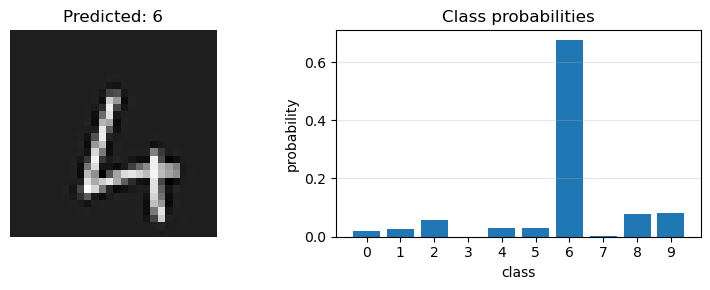

In [15]:
from src.utils import (
    predict_drawn_digit,
    show_drawn_digit_prediction,
)
# Edit this path to your saved PNG
image_path = "4.png"

# If your image background is white and digit is black, set invert_input=True
pred, probs = predict_drawn_digit(cnn_model, image_path, device, invert_input=False)
show_drawn_digit_prediction(image_path, pred, probs, invert_input=False)

What does the result say? Is it wrong? If it is wrong is it _confidently_ wrong? 

This is an important point to understand. A model can not just be wrong, but also be confidently wrong. This is a problem because it can lead to over-reliance on the model's predictions, even when they are incorrect.



# Assignment 

- Incrementally increase the number of training examples and compare the performance of a CNN and an FC network on the CIFAR-10 dataset.

- Use 1%, 5%, 10%, 50%, and 100% of the training data to train both models and plot the *test* performance as a function of number of training examples for both models.

- Use the same test set for both models to compare their performance.


In [3]:
fractions = [0.01, 0.05, 0.1, 0.5, 1.0]
results_cnn_fractions = {}
results_fc_fractions = {}



/Users/alokbharadwaj/miniconda3/envs/ai4bio/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 704  (45000 examples)
Val batches:   79  (5000 examples)
Test batches:  157  (10000 examples)


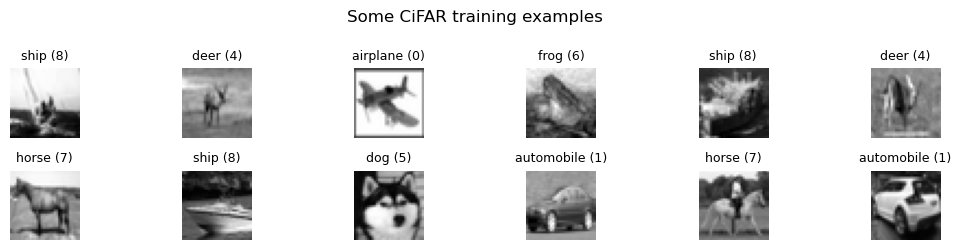

In [1]:
from src.utils import get_cifar10_loaders, show_examples

train_loader, val_loader, test_loader = get_cifar10_loaders(
    batch_size=64,
    val_fraction=0.1,
    train_subset_size=None,   # <-- set to e.g. 1000 to deliberately induce overfitting
    seed=0,
)

print(f"Train batches: {len(train_loader)}  ({len(train_loader.dataset)} examples)")
print(f"Val batches:   {len(val_loader)}  ({len(val_loader.dataset)} examples)")
print(f"Test batches:  {len(test_loader)}  ({len(test_loader.dataset)} examples)")
# Display CiFAR-10 class names
cifar10_classes = {0: "airplane", 1: "automobile", 2: "bird", 3: "cat", 4: "deer",\
                   5: "dog", 6: "frog", 7: "horse", 8: "ship", 9: "truck"}

show_examples(train_loader, n=12, title="Some CiFAR training examples", classes=cifar10_classes);



In [6]:

from src.utils import get_subset, set_seed

training_dataloaders = {}
for frac in fractions:
    subset_loader = get_subset(train_loader.dataset, fraction=frac, seed=0, batch_size=BATCH_SIZE)
    training_dataloaders[frac] = subset_loader


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for frac in fractions:
    print(f"\nTraining with {frac*100:.2f}% of training data...")
    set_seed(0)
    cnn_model_frac = CNN(in_channels=1, num_classes=10, image_size=32)
    fc_model_frac = FCNet(input_dim=32*32, hidden_size=32, num_hidden=1, output_dim=10)
    print(f"Number of parameters - CNN: {sum(p.numel() for p in cnn_model_frac.parameters())}, "
          f"FCNet: {sum(p.numel() for p in fc_model_frac.parameters())}")
    
    result_cnn = train_model(
        model=cnn_model_frac.to(device),
        train_loader=training_dataloaders[frac],
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        device=device,
    )
    results_cnn_fractions[frac] = result_cnn
    
    result_fc = train_model(
        model=fc_model_frac.to(device),
        train_loader=training_dataloaders[frac],
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        device=device,
    )
    results_fc_fractions[frac] = result_fc



Training with 1.00% of training data...
Number of parameters - CNN: 3322, FCNet: 34186
Training CNN for 10 epochs...
Epoch 1/10 - Train Loss: 2.3018 - Val Loss: 2.3041 - Val Acc: 0.1008
Epoch 2/10 - Train Loss: 2.3007 - Val Loss: 2.3043 - Val Acc: 0.1008
Epoch 3/10 - Train Loss: 2.2993 - Val Loss: 2.3042 - Val Acc: 0.1008
Epoch 4/10 - Train Loss: 2.2980 - Val Loss: 2.3040 - Val Acc: 0.1008
Epoch 5/10 - Train Loss: 2.2946 - Val Loss: 2.3030 - Val Acc: 0.1008
Epoch 6/10 - Train Loss: 2.2917 - Val Loss: 2.3034 - Val Acc: 0.1008
Epoch 7/10 - Train Loss: 2.2879 - Val Loss: 2.3046 - Val Acc: 0.1008
Epoch 8/10 - Train Loss: 2.2838 - Val Loss: 2.3015 - Val Acc: 0.1008
Epoch 9/10 - Train Loss: 2.2789 - Val Loss: 2.2986 - Val Acc: 0.1008
Epoch 10/10 - Train Loss: 2.2774 - Val Loss: 2.2943 - Val Acc: 0.1168
Training FCNet for 10 epochs...
Epoch 1/10 - Train Loss: 2.1919 - Val Loss: 2.2611 - Val Acc: 0.1534
Epoch 2/10 - Train Loss: 2.1120 - Val Loss: 2.2403 - Val Acc: 0.1924
Epoch 3/10 - Train Lo

In [15]:
test_accuracies_cnn = {}
test_accuracies_fc = {}
criterion = nn.CrossEntropyLoss()
for frac in fractions:
    cnn_model = results_cnn_fractions[frac]["trained_model"]
    fc_model = results_fc_fractions[frac]["trained_model"]
    test_loss_cnn, test_acc_cnn = evaluate(cnn_model, test_loader, criterion, device)
    test_loss_fc, test_acc_fc = evaluate(fc_model, test_loader, criterion, device)
    test_accuracies_cnn[frac] = test_acc_cnn
    test_accuracies_fc[frac] = test_acc_fc
    print(f"Fraction: {frac*100:.2f}% - CNN Test Acc: {test_acc_cnn:.4f} - FCNet Test Acc: {test_acc_fc:.4f}")
    

Fraction: 1.00% - CNN Test Acc: 0.1160 - FCNet Test Acc: 0.2188
Fraction: 5.00% - CNN Test Acc: 0.2982 - FCNet Test Acc: 0.2947
Fraction: 10.00% - CNN Test Acc: 0.3388 - FCNet Test Acc: 0.3147
Fraction: 50.00% - CNN Test Acc: 0.4429 - FCNet Test Acc: 0.3726
Fraction: 100.00% - CNN Test Acc: 0.4835 - FCNet Test Acc: 0.3953


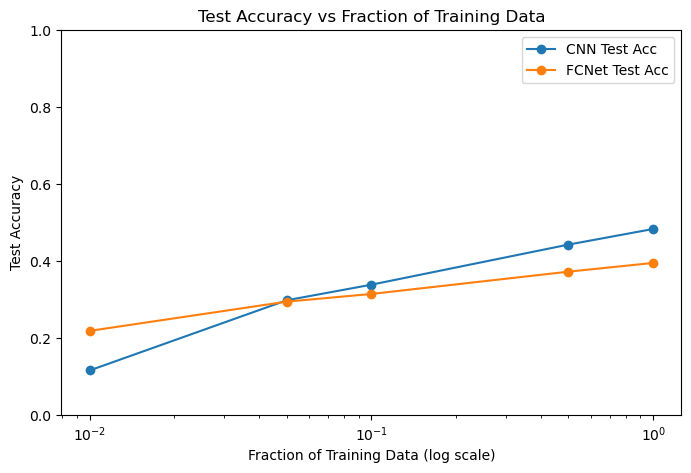

In [17]:
# plot test accuracies vs fraction of training data
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(fractions, [test_accuracies_cnn[frac] for frac in fractions], marker='o', label='CNN Test Acc')
plt.plot(fractions, [test_accuracies_fc[frac] for frac in fractions], marker='o', label='FCNet Test Acc')
plt.xscale('log')
plt.xlabel('Fraction of Training Data (log scale)')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs Fraction of Training Data')
plt.ylim(0, 1)
plt.legend()

In [18]:
# Upload the results to Surfdrive
from src.utils import upload_to_surfdrive
results_dictionary = {
    "cnn_results": results_cnn_fractions,
    "fc_results": results_fc_fractions,
}

upload_to_surfdrive(results_dictionary=results_dictionary)
    

✓ Uploaded as: alok_1234_20260429_200815_submission.pkl
